In [1]:

from __future__ import print_function   # print versi baru
%matplotlib inline                     
import numpy                            # pustaka numerik
import matplotlib.pyplot as plt         # pustaka grafik

# Iterative Methods
Metode Iteratif adalah cara menyelesaikan sebuah perhitungan matematika dengan melakukan pengulangan (langkah demi langkah) sampai mendapatkan hasil yang paling mendekati benar.

### Cara Menyelesaikan $A u = f$

Kita sudah mencoba menyelesaikan sistem linear $A u = f$ menggunakan perintah `numpy.linalg.solve`. Namun, karena matriks $A$ di sini memiliki struktur yang unik, kita bisa menggunakan cara yang lebih efektif.



### Metode Langsung (Eliminasi Gauss)

Eliminasi Gauss memang memberikan jawaban pasti, tapi sangat berat dan lambat jika datanya besar.

#### Beban Komputasi (Seberapa Berat Hitungannya?)

Bayangkan kita punya masalah 3D dengan 1 juta variabel yang tidak diketahui. Jika kita menggunakan Eliminasi Gauss:

* Total Operasi: Dibutuhkan sekitar $10^{18}$ hitungan (angka 1 diikuti 18 nol).
* Kecepatan Komputer: Misalkan komputer kita sangat cepat (100 Gigaflops).
* Waktu Tunggu: $$\frac{10^{18}}{10^{11}} = 10^7 \text{ detik} \approx \mathbf{115\ hari!}$$



#### Beban Memori (Kuatkah RAM Kita?)

Bagaimana dengan penggunaan memori komputer?

Untuk menyimpan seluruh data matriks berukuran $10^6$, kita butuh:
* Kapasitas: $8 \times 10^{12}$ bytes = 8 Terabyte.

Jika kita menggunakan metode biasa, kita harus menyimpan semua angka di dalam RAM. 

* Masalahnya: Laptop standar biasanya hanya punya RAM 8 GB atau 16 GB. 
* Kebutuhannya: Cara ini butuh 8.000 GB (8 TB). RAM laptop kita pasti tidak akan kuat dan program akan langsung crash.

Pakai Metode Iteratif. Kita tidak perlu menyimpan seluruh isi matriks (terutama angka nolnya), sehingga RAM yang dibutuhkan jauh lebih kecil. Sebenarnya situasinya tidak separah yang dibayangkan, asalkan kita memanfaatkan sifat sparse (banyak angka nol) pada matriks tersebut.

### Metode Iteratif

Metode iteratif menggunakan pendekatan yang berbeda dari metode langsung. Jika kita memiliki sistem Ax = b, kita membuat prosedur pengulangan menggunakan sebuah fungsi (misalnya L) sedemikian rupa sehingga:

$$\hat{x}^{(k)} = L(\hat{x}^{(k-1)})$$

Tujuannya adalah agar selisih (error) antara jawaban asli x dengan hasil tebakan kita x^(k) semakin lama semakin mendekati nol seiring bertambahnya jumlah pengulangan (k). Kita akan mempelajari metode-metode ini lebih dalam pada pertemuan berikutnya.



### Jacobi dan Gauss-Seidel

Metode Jacobi dan Gauss-Seidel adalah cara sederhana untuk menyelesaikan persamaan $Ax = b$ melalui pengulangan, terutama saat matriks $A$ memiliki banyak angka nol. Sebagai contoh, pada masalah Poisson $u_{xx} = f(x)$, kita menggunakan pendekatan selisih hingga pada titik $x_i$ dengan rumus:

$$\frac{U_{i-1} - 2 U_i + U_{i+1}}{\Delta x^2} = f(x_i)$$

Intinya, metode ini mengubah persamaan diferensial yang rumit menjadi hitungan aljabar biasa agar kita bisa mencari nilai di setiap titik satu per satu secara berulang sampai mendapatkan hasil akhir yang akurat.

### Iterasi Jacobi

Metode Jacobi adalah cara sederhana untuk menyelesaikan masalah $Ax = b$ pada matriks yang jarang terisi (sparse) melalui proses pengulangan. Jika kita menggunakan pendekatan selisih hingga pada titik $x_i$, persamaannya menjadi:

$$\frac{U_{i-1} - 2 U_i + U_{i+1}}{\Delta x^2} = f(x_i)$$

Jika rumus tersebut diatur ulang untuk mencari nilai $U_i$, maka hasilnya adalah:

$$U_i = \frac{1}{2} (U_{i+1} + U_{i-1}) - f(x_i) \frac{\Delta x^2}{2}$$



Berbeda dengan metode langsung yang menghitung semua nilai sekaligus, metode iterasi ini memperbarui nilai setiap titik menggunakan data yang sudah diketahui dari langkah sebelumnya:

$$U_i^{(k+1)} = \frac{1}{2} (U_{i+1}^{(k)} + U_{i-1}^{(k)}) - f(x_i) \frac{\Delta x^2}{2}$$

Karena kita bisa langsung menghitung $U_i^{(k+1)}$ hanya dengan nilai lama, proses ini disebut Iterasi Jacobi. 
* Matriks $A$ tidak perlu dibuat atau disimpan, sehingga sangat hemat memori.
* Penyimpanan data sangat efisien (optimal).
* Jumlah operasi hitung setiap putaran hanya sebanding dengan jumlah variabel yang dicari.

### Contoh

Mari selesaikan soal BVP sebelumnya menggunakan iterasi Jacobi sebagai pengganti metode langsung:

$$u_{xx} = e^x, \quad x \in [0, 1] \quad \text{dengan} \quad u(0) = 0.0, \text{ dan } u(1) = 3$$

Kita akan menghitung nilai $u$ secara bertahap hingga kurvanya stabil dan sesuai dengan batas yang ditentukan.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20208\663672972.py:102: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  axes.plot(x_bc, u_true(x_bc), 'k',


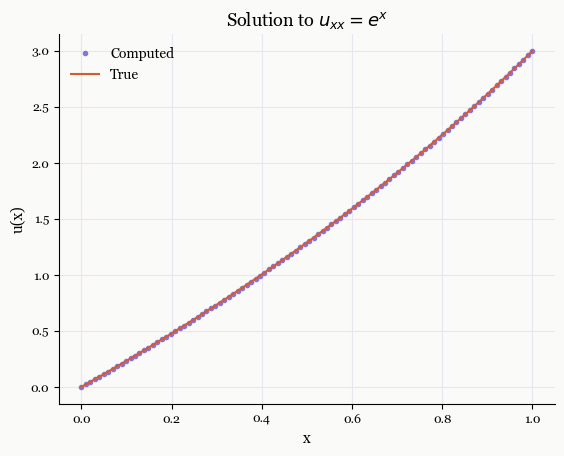

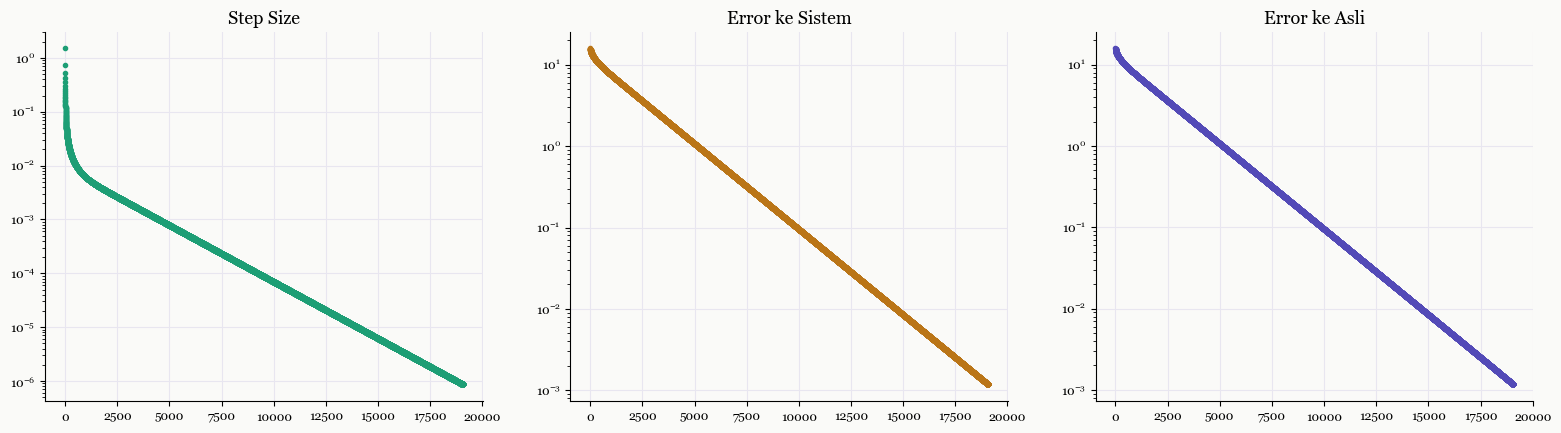

In [ ]:
import numpy
import matplotlib.pyplot as plt

# Model
plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Georgia', 'Palatino', 'DejaVu Serif'],
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Problem setup
a = 0.0                  # batas kiri
b = 1.0                  # batas kanan
u_a = 0.0                # nilai kiri
u_b = 3.0                # nilai kanan
f = lambda x: numpy.exp(x)   # fungsi e^x
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)
# solusi analitik

def U_true(a, b, u_a, u_b, f, m):
    """Compute the solution to the given linear system"""
    
    x_bc = numpy.linspace(a, b, m + 2)   # semua titik
    x = x_bc[1:-1]                       # titik dalam
    delta_x = (b - a) / (m + 1)          # jarak titik
    
    # Construct matrix A
    A = numpy.zeros((m, m))              # matriks kosong
    diagonal = numpy.ones(m) / delta_x**2  # nilai diagonal
    
    A += numpy.diag(diagonal * -2.0, 0)     # diagonal utama
    A += numpy.diag(diagonal[:-1], 1)       # diagonal atas
    A += numpy.diag(diagonal[:-1], -1)      # diagonal bawah

    # Construct RHS
    b = f(x)                    # sisi kanan
    b[0] -= u_a / delta_x**2    # koreksi kiri
    b[-1] -= u_b / delta_x**2   # koreksi kanan

    # Solve system
    U = numpy.empty(m + 2)      # array solusi
    U[0] = u_a                  # isi kiri
    U[-1] = u_b                 # isi kanan
    U[1:-1] = numpy.linalg.solve(A, b)  # solusi langsung
    
    return U

# Discretization
m = 100                         # jumlah grid
x_bc = numpy.linspace(a, b, m + 2)   # titik grid
x = x_bc[1:-1]                       # titik dalam
delta_x = (b - a) / (m + 1)          # jarak grid

# Expected iterations needed
iterations_J = int(2.0 * numpy.log(delta_x) / 
                   numpy.log(1.0 - 0.5 * numpy.pi**2 * delta_x**2))
# perkiraan iterasi

# Solve system langsung
U_system = U_true(a, b, u_a, u_b, f, m)   # solusi matriks
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)
# error awal

# Initial guess Jacobi
U_new = numpy.zeros(m + 2)   # tebakan awal
U_new[0] = u_a               # batas kiri tetap
U_new[-1] = u_b              # batas kanan tetap

convergence_J = numpy.zeros((iterations_J, 2))  # simpan error
step_size_J = numpy.zeros(iterations_J)         # simpan perubahan

# Iterasi Jacobi
for k in range(iterations_J):
    U = U_new.copy()            # salin lama
    
    for i in range(1, m + 1):
        U_new[i] = 0.5 * (U[i+1] + U[i-1]) \
                   - f(x_bc[i]) * delta_x**2 / 2.0
        # rumus Jacobi

    step_size_J[k] = numpy.linalg.norm(U - U_new, ord=2)
    # besar perubahan
    
    convergence_J[k, 0] = numpy.linalg.norm(U_system - U_new, ord=2)
    # error ke sistem
    
    convergence_J[k, 1] = numpy.linalg.norm(u_true(x_bc) - U_new, ord=2)
    # error ke asli
        
# Plot hasil solusi
fig = plt.figure(facecolor='#FAFAF8')
axes = fig.add_subplot(1, 1, 1)
axes.set_facecolor('#FAFAF8')

axes.plot(x_bc, U_new, 'o',
          color='#7F77DD', markersize=3, label="Computed")   # hasil Jacobi — ungu
axes.plot(x_bc, u_true(x_bc), 'k',
          color='#D85A30', label="True")                     # solusi asli — coral

axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
axes.legend(frameon=False)
axes.grid(True, color='#E8E6F0', linewidth=0.8)

# Plot grafik konvergensi
fig = plt.figure(facecolor='#FAFAF8')
fig.set_figwidth(fig.get_figwidth() * 3)

# Grafik perubahan
axes = fig.add_subplot(1, 3, 1)
axes.set_facecolor('#FAFAF8')
axes.semilogy(range(iterations_J), step_size_J, 'o',
              color='#1D9E75', markersize=3)   # teal
axes.set_title("Step Size")
axes.grid(True, color='#E8E6F0', linewidth=0.8)

# Grafik error sistem
axes = fig.add_subplot(1, 3, 2)
axes.set_facecolor('#FAFAF8')
axes.semilogy(range(iterations_J), convergence_J[:, 0], 'o',
              color='#BA7517', markersize=3)   # amber
axes.set_title("Error ke Sistem")
axes.grid(True, color='#E8E6F0', linewidth=0.8)

# Grafik error asli
axes = fig.add_subplot(1, 3, 3)
axes.set_facecolor('#FAFAF8')
axes.semilogy(range(iterations_J), convergence_J[:, 1], 'o',
              color='#534AB7', markersize=3)   # ungu gelap
axes.set_title("Error ke Asli")
axes.grid(True, color='#E8E6F0', linewidth=0.8)

plt.show()   # tampilkan grafik

# Metode Gauss-Seidel

Metode Gauss-Seidel adalah perbaikan kecil dari metode sebelumnya. Rumusnya sekarang menjadi:

$$
U_i^{(k+1)} = \frac{1}{2} (U_{i+1}^{(k)} + U_{i-1}^{(k+1)}) - f(x_i) \frac{\Delta x^2}{2}
$$

Perbedaannya sederhana: nilai di sebelah kiri langsung pakai hasil baru yang baru dihitung, sedangkan nilai di sebelah kanan masih pakai hasil lama. Ini membuat perhitungan lebih cepat karena langsung memanfaatkan data terbaru.

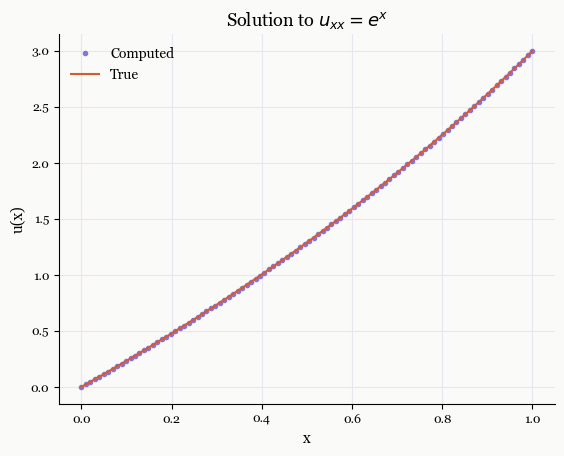

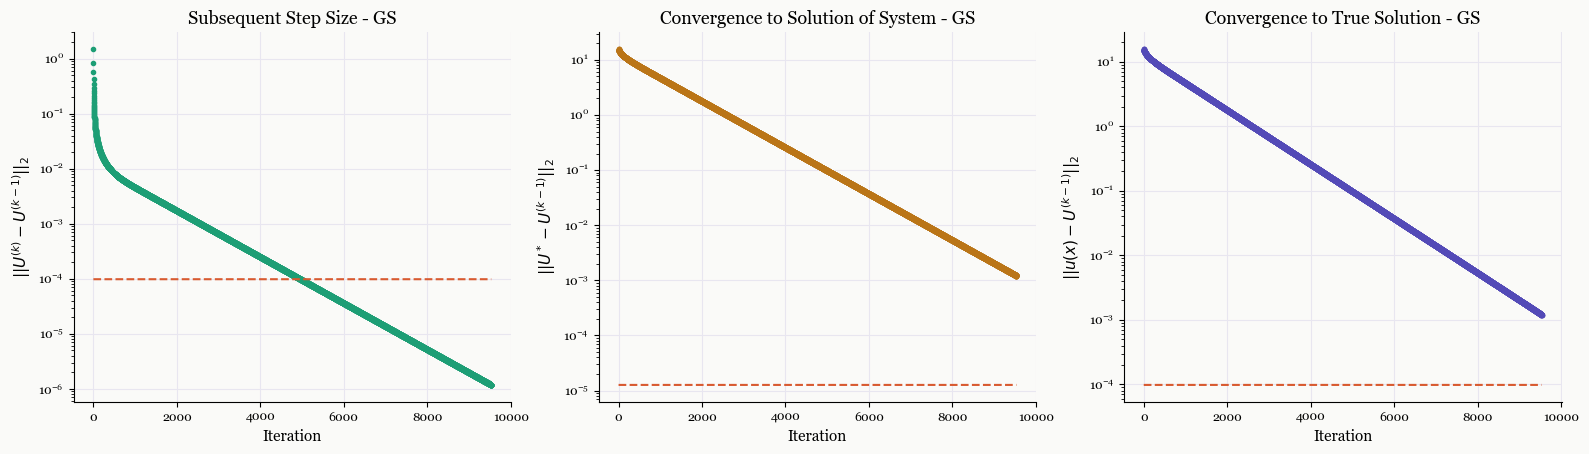

In [ ]:
import numpy
import matplotlib.pyplot as plt

# Model
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Georgia', 'Palatino', 'DejaVu Serif'],
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Problem setup
a = 0.0                     # batas kiri domain
b = 1.0                     # batas kanan domain
u_a = 0.0                   # nilai batas kiri
u_b = 3.0                   # nilai batas kanan
f = lambda x: numpy.exp(x)  # fungsi sumber e^x
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  # solusi analitik sebenarnya

# Descretization
m = 100                                 # jumlah titik interior
x_bc = numpy.linspace(a, b, m + 2)      # grid termasuk batas
x = x_bc[1:-1]                          # grid tanpa batas
delta_x = (b - a) / (m + 1)             # ukuran langkah grid

# Expected iterations needed
iterations_GS = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - numpy.pi**2 * delta_x**2))  
# estimasi iterasi Gauss-Seidel

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)  # solusi sistem eksak
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)  
# error solusi sistem

# Initial guess for iterations
U = numpy.zeros(m + 2)              # tebakan awal nol
U[0] = u_a                          # set batas kiri
U[-1] = u_b                         # set batas kanan
convergence_GS = numpy.zeros((iterations_GS, 2))  # simpan data konvergensi
step_size_GS = numpy.zeros(iterations_GS)         # simpan ukuran langkah
success = False                     # status konvergensi awal

for k in range(iterations_GS):      # iterasi Gauss-Seidel
    U_old = U.copy()                # simpan solusi sebelumnya
    for i in range(1, m + 1):       # loop titik interior
        U[i] = 0.5 * (U[i+1] + U[i-1]) - f(x_bc[i]) * delta_x**2 / 2.0  
        # update rumus Gauss-Seidel

    convergence_GS[k, 0] = numpy.linalg.norm(U_system - U, ord=2)  
    # error ke solusi sistem
    convergence_GS[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)  
    # error ke solusi asli
    step_size_GS[k] = numpy.linalg.norm(U_old - U, ord=2)  
    # beda iterasi berturut

# Plot result
fig = plt.figure(facecolor='#FAFAF8')                  # buat figure baru
axes = fig.add_subplot(1, 1, 1)                        # satu subplot
axes.set_facecolor('#FAFAF8')
axes.plot(x_bc, U, 'o',
          color='#7F77DD', markersize=3, label="Computed")  # plot solusi numerik
axes.plot(x_bc, u_true(x_bc),
          color='#D85A30', label="True")                    
# plot solusi analitik
axes.set_title("Solution to $u_{xx} = e^x$")  # judul grafik
axes.set_xlabel("x")                          # label sumbu x
axes.set_ylabel("u(x)")                       # label sumbu y
axes.legend(frameon=False)
axes.grid(True, color='#E8E6F0', linewidth=0.8)

fig = plt.figure(facecolor='#FAFAF8')                    # figure kedua
fig.set_figwidth(fig.get_figwidth() * 3)                 # perlebar ukuran figure

axes = fig.add_subplot(1, 3, 1)                          # subplot pertama
axes.set_facecolor('#FAFAF8')
axes.semilogy(list(range(iterations_GS)), step_size_GS, 'o',
              color='#1D9E75', markersize=3)  
# plot ukuran langkah
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, '--',
              color='#D85A30')  
# batas toleransi teori
axes.set_title("Subsequent Step Size - GS")   # judul subplot satu
axes.set_xlabel("Iteration")                  # label iterasi
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")  
# norma beda solusi
axes.grid(True, color='#E8E6F0', linewidth=0.8)

axes = fig.add_subplot(1, 3, 2)                          # subplot kedua
axes.set_facecolor('#FAFAF8')
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 0], 'o',
              color='#BA7517', markersize=3)  
# plot error sistem
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * epsilon, '--',
              color='#D85A30')  
# batas error sistem
axes.set_title("Convergence to Solution of System - GS")  
# judul subplot dua
axes.set_xlabel("Iteration")                  # label iterasi
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")    
# norma error sistem
axes.grid(True, color='#E8E6F0', linewidth=0.8)

axes = fig.add_subplot(1, 3, 3)                          # subplot ketiga
axes.set_facecolor('#FAFAF8')
axes.semilogy(list(range(iterations_GS)), convergence_GS[:, 1], 'o',
              color='#534AB7', markersize=3)  
# plot error solusi asli
axes.semilogy(list(range(iterations_GS)), numpy.ones(iterations_GS) * delta_x**2, '--',
              color='#D85A30')  
# batas error teoritis
axes.set_title("Convergence to True Solution - GS")  
# judul subplot tiga
axes.set_xlabel("Iteration")                  # label iterasi
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")   
# norma error asli
axes.grid(True, color='#E8E6F0', linewidth=0.8)

plt.show()    # tampilkan semua grafik

# Metode Pemisahan Matriks

Cara lain untuk memahami metode Jacobi dan Gauss-Seidel adalah dengan memisahkan matriks A menjadi:

$$
A = M - N
$$

Maka sistem persamaan $A U = b$ bisa ditulis sebagai:

$$
M U - N U = b \Rightarrow MU = NU + b
$$

Jika kita ubah menjadi proses iterasi, maka bentuknya:

$$
M U^{(k+1)} = N U^{(k)} + b
$$

Tujuannya adalah memilih M dan N sedemikian rupa sehingga M mengandung sebanyak mungkin bagian dari A, tetapi tetap lebih mudah diselesaikan dibandingkan sistem aslinya.

# Rumus Pembaruan Iterasi

Rumus pembaruan untuk setiap metode menjadi:

$$
U^{(k+1)} = M^{-1} N U^{(k)} + M^{-1} b = G U^{(k)} + c
$$

di mana G disebut **matriks iterasi** dan $c = M^{-1} b$. Kita juga ingin:

$$
u = G u + c
$$

dengan u adalah solusi sebenarnya dari persamaan awal $A u = b$. Dengan kata lain, u adalah titik tetap dari iterasi ini. Tapi apakah titik tetap ini stabil? Jika radius spektral $\rho(G) < 1$, maka iterasi ini stabil.

Perhatikan kemiripan antara analisis kestabilan kita yang menggunakan $||A^{-1}||$ dengan sekarang $G = M^{-1} N$ yang mirip tapi tidak sama persis.

Untuk metode Jacobi, pemisahannya adalah:

$$
M = -\frac{2}{\Delta x^2} I, \quad \text{dan}\quad N = -\frac{1}{\Delta x^2} \begin{bmatrix}
    0 & 1 & \\
    1 & 0 & 1 \\
      & \ddots & \ddots & \ddots \\
      & & 1 & 0 & 1 \\
      & &   & 1 & 0
\end{bmatrix}
$$

(untuk masalah Poisson). M sekarang adalah matriks diagonal dan mudah diselesaikan.

Untuk metode Gauss-Seidel kita punya:

$$
M = \frac{1}{\Delta x^2} \begin{bmatrix}
    -2 &  & \\
     1 & -2 &  \\
       & \ddots & \ddots \\
       & & 1 & -2 & \\
       & &   & 1 & -2
\end{bmatrix} \quad \text{dan} \quad 
N = -\frac{1}{\Delta x^2} \begin{bmatrix}
     0 & 1 & \\
      & 0 & 1 \\
      & & \ddots & \ddots \\
       & &  & 0 & 1\\
       & &   &  & 0
\end{bmatrix}
$$

# Kriteria Berhenti

Berapa banyak iterasi yang harus kita lakukan? Misalkan $E^{(k)}$ adalah kesalahan pada langkah ke-k. Jika kita ingin mengurangi kesalahan awal $E^{(0)}$ sampai orde $\epsilon$, maka:

$$
||E^{(k)}|| \approx \epsilon ||E^{(0)}||
$$

Dengan asumsi tertentu, kita bisa membatasi kesalahan dalam norma-2 sebagai:

$$
||E^{(k)}||_2 \leq \rho(G)^k ||E^{(0)}||_2
$$

di mana $\rho(G)$ adalah radius spektral dari matriks iterasi.

Dengan menggabungkan kedua persamaan kesalahan E dan mengambil $\Delta x \rightarrow 0$, kita dapat menulis:

$$
k \approx \frac{\log \epsilon}{\log \rho(G)}
$$

dengan mempertimbangkan konvergensi kesalahan.

Memilih $\epsilon$ agak rumit, tetapi kriteria alami yang bisa digunakan adalah $\epsilon = \mathcal{O}(\Delta x^2)$ karena diskretisasi awal kita akurat orde kedua. Ini menghasilkan:

$$
k = \frac{2 \log \Delta x}{\log \rho}
$$

Ini juga memungkinkan kita memperkirakan total operasi yang diperlukan.

Untuk Jacobi, radius spektral dari G adalah:

$$
\rho_J \approx 1 - \frac{1}{2} \pi^2 \Delta x^2
$$

sehingga:

$$
k = \mathcal{O}(m^2 \log m) \quad \text{ketika} \quad m \rightarrow \infty
$$

Digabungkan dengan jumlah operasi per iterasi sebelumnya, Jacobi menghasilkan $\mathcal{O}(m^3 \log m)$ operasi yang kurang menjanjikan.

Untuk dua dimensi kita punya $\mathcal{O}(m^4 \log m)$, jadi bahkan dibandingkan eliminasi Gaussian, pendekatan ini tidak ideal.

Bagaimana dengan Gauss-Seidel? Di sini radius spektralnya kira-kira:

$$
\rho_{GS} \approx 1 - \pi^2 \Delta x^2
$$

sehingga:

$$
k = \frac{2 \times \log \Delta x}{\log (1 - \pi^2 \Delta x^2)}
$$

yang masih tidak memberikan keuntungan dibanding metode langsung. Namun ini menunjukkan bahwa Gauss-Seidel memang konvergen lebih cepat karena perbedaan faktor 2 antara $\rho_J$ dan $\rho_{GS}$.

# Successive Overrelaxation (SOR)

Hasil sebelumnya memang agak mengecewakan bukan? Skema iteratif ini tampaknya tidak terlalu berguna, tetapi ternyata kita bisa melakukan lebih baik dengan sedikit modifikasi pada Gauss-Seidel.

Jika kita perhatikan iterasi Gauss-Seidel, ternyata metode ini menggerakkan U ke arah yang benar menuju u tetapi terlalu konservatif dalam jumlahnya. Jika kita melakukan:

$$\begin{aligned}
    U^{GS}_i &= \frac{1}{2} \left(U^{(k+1)}_{i-1} + U^{(k)}_{i+1} - \Delta x^2 f_i\right) \\
    U^{(k+1)}_i &= U_i^{(k)} + \omega \left( U_i^{GS} - U_i^{(k)}\right )
\end{aligned}$$

di mana kita bisa memilih $\omega$, hasilnya bisa jauh lebih baik.

Jika $\omega = 1$ maka kita mendapat kembali Gauss-Seidel.

Jika $\omega < 1$ kita bergerak lebih sedikit dan konvergen lebih lambat lagi (meskipun kadang digunakan untuk multigrid dengan nama **underrelaxation**).

Jika $\omega > 1$ maka kita bergerak lebih jauh dari yang disarankan Gauss-Seidel dan metode dengan $\omega > 1$ dikenal sebagai **successive overrelaxation** (SOR).

Kita juga bisa menuliskan ini sebagai metode pemisahan matriks. Dengan menggabungkan dua rumus di atas kita dapatkan:

$$
U^{(k+1)}_i = \frac{\omega}{2} \left( U^{(k+1)}_{i-1} + U^{(k)}_{i+1} - \Delta x^2 f_i \right ) + (1 - \omega) U_i^{(k)}
$$

yang sesuai dengan pemisahan matriks:

$$
M = \frac{1}{\omega} (D - \omega L) \quad \text{dan} \quad N = \frac{1}{\omega} ((1-\omega) D + \omega U)
$$

di mana D adalah diagonal matriks A, dan L serta U adalah bagian segitiga bawah dan atas tanpa diagonal dari A.

Dapat ditunjukkan bahwa dengan memilih $\omega$ sehingga $0 < \omega < 2$, metode SOR akan konvergen.

Ternyata kita juga bisa menemukan $\omega$ optimal untuk kelas masalah yang luas. Untuk masalah Poisson dalam dimensi ruang berapapun misalnya, dapat ditunjukkan bahwa metode SOR konvergen optimal jika:

$$
\omega_{opt} = \frac{2}{1 + \sin(\pi \Delta x)} \approx 2 - 2 \pi \Delta x
$$

Bagaimana dengan jumlah iterasinya? Kita bisa mengikuti taktik yang sama seperti sebelumnya dengan radius spektral dari $G_{SOR}$ sekarang:

$$
\rho = \omega_{opt} - 1 \approx 1 - 2 \pi \Delta x
$$

Ini menghasilkan jumlah iterasi:

$$
k = \mathcal{O}(m \log m)
$$

satu orde lebih baik dari Gauss-Seidel saja!

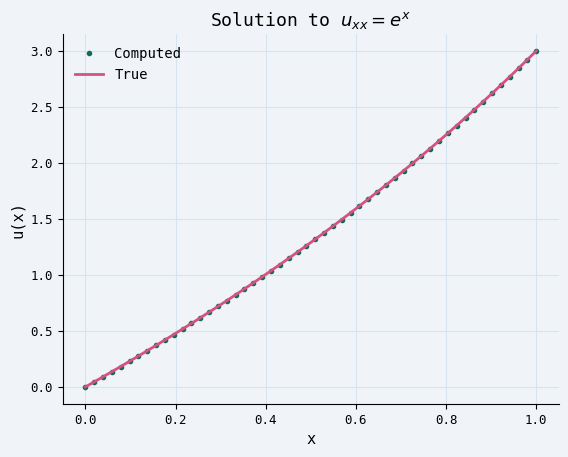

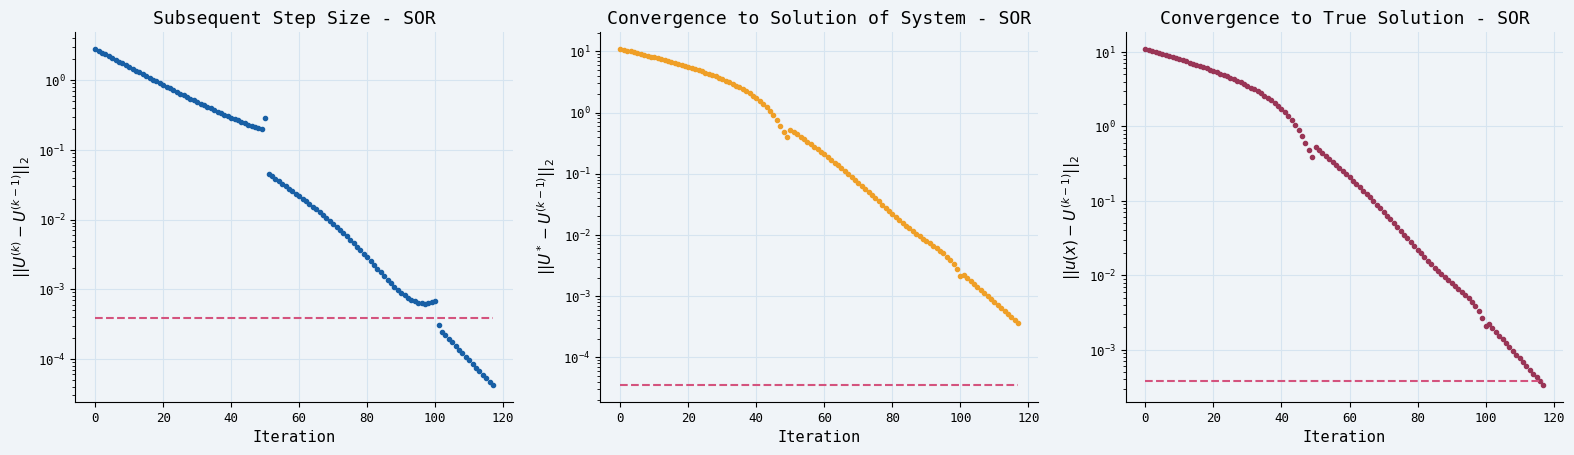

In [ ]:
import numpy
import matplotlib.pyplot as plt

# Model
plt.rcParams.update({
    'font.family':       'monospace',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Problem setup
a = 0.0                     # batas kiri domain
b = 1.0                     # batas kanan domain
u_a = 0.0                   # nilai batas kiri
u_b = 3.0                   # nilai batas kanan
f = lambda x: numpy.exp(x)  # fungsi sumber e^x
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  
# solusi analitik sebenarnya

# Descretization
m = 50                                  # jumlah titik interior
x_bc = numpy.linspace(a, b, m + 2)      # grid termasuk batas
x = x_bc[1:-1]                          # grid tanpa batas
delta_x = (b - a) / (m + 1)             # ukuran langkah grid

# SOR parameter
omega = 2.0 / (1.0 + numpy.sin(numpy.pi * delta_x))  
# parameter relaksasi optimal

# Expected iterations needed
iterations_SOR = int(2.0 * numpy.log(delta_x) / numpy.log(1.0 - 2.0 * numpy.pi * delta_x)) * 2  
# estimasi iterasi metode SOR

# Solve system
U_system = U_true(a, b, u_a, u_b, f, m)  # solusi sistem eksak
epsilon = numpy.linalg.norm(u_true(x_bc) - U_system, ord=2)  
# error solusi sistem

# Initial guess for iterations
U = numpy.zeros(m + 2)              # tebakan awal nol
U[0] = u_a                          # set batas kiri
U[-1] = u_b                         # set batas kanan
step_size_SOR = numpy.zeros(iterations_SOR)  
# simpan ukuran langkah
convergence_SOR = numpy.zeros((iterations_SOR, 2))  
# simpan data konvergensi

for k in range(iterations_SOR):      # iterasi metode SOR
    U_old = U.copy()                 # simpan solusi lama
    for i in range(1, m + 1):        # loop titik interior
        U_gs = 0.5 * (U[i-1] + U[i+1] - delta_x**2 * f(x_bc[i]))  
        # rumus Gauss-Seidel dasar
        U[i] += omega * (U_gs - U[i])  
        # update relaksasi SOR

    step_size_SOR[k] = numpy.linalg.norm(U_old - U, ord=2)  
    # beda iterasi berturut
    convergence_SOR[k, 0] = numpy.linalg.norm(U_system - U, ord=2)  
    # error ke solusi sistem
    convergence_SOR[k, 1] = numpy.linalg.norm(u_true(x_bc) - U, ord=2)  
    # error ke solusi asli
        
# Plot result
fig = plt.figure(facecolor='#F0F4F8')                  # buat figure baru
axes = fig.add_subplot(1, 1, 1)                        # satu subplot
axes.set_facecolor('#F0F4F8')
axes.plot(x_bc, U, 'o',
          color='#0F6E56', markersize=3, label="Computed")  # plot solusi numerik
axes.plot(x_bc, u_true(x_bc),
          color='#D4537E', linewidth=2, label="True")  
# plot solusi analitik
axes.set_title("Solution to $u_{xx} = e^x$")  # judul grafik
axes.set_xlabel("x")                          # label sumbu x
axes.set_ylabel("u(x)")                       # label sumbu y
axes.legend(frameon=False)
axes.grid(True, color='#D6E4F0', linewidth=0.8)

fig = plt.figure(facecolor='#F0F4F8')                    # figure kedua
fig.set_figwidth(fig.get_figwidth() * 3)                 # perlebar ukuran figure

axes = fig.add_subplot(1, 3, 1)                          # subplot pertama
axes.set_facecolor('#F0F4F8')
axes.semilogy(list(range(iterations_SOR)), step_size_SOR, 'o',
              color='#185FA5', markersize=3)  
# plot ukuran langkah
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * delta_x**2, '--',
              color='#D4537E', linewidth=1.5)  
# batas toleransi teori
axes.set_title("Subsequent Step Size - SOR")  # judul subplot satu
axes.set_xlabel("Iteration")                  # label iterasi
axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")  
# norma beda solusi
axes.grid(True, color='#D6E4F0', linewidth=0.8)

axes = fig.add_subplot(1, 3, 2)                          # subplot kedua
axes.set_facecolor('#F0F4F8')
axes.semilogy(list(range(iterations_SOR)), convergence_SOR[:, 0], 'o',
              color='#EF9F27', markersize=3)  
# plot error sistem
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * epsilon, '--',
              color='#D4537E', linewidth=1.5)  
# batas error sistem
axes.set_title("Convergence to Solution of System - SOR")  
# judul subplot dua
axes.set_xlabel("Iteration")                  # label iterasi
axes.set_ylabel("$||U^* - U^{(k-1)}||_2$")    
# norma error sistem
axes.grid(True, color='#D6E4F0', linewidth=0.8)

axes = fig.add_subplot(1, 3, 3)                          # subplot ketiga
axes.set_facecolor('#F0F4F8')
axes.semilogy(list(range(iterations_SOR)), convergence_SOR[:, 1], 'o',
              color='#993556', markersize=3)  
# plot error solusi asli
axes.semilogy(list(range(iterations_SOR)), numpy.ones(iterations_SOR) * delta_x**2, '--',
              color='#D4537E', linewidth=1.5)  
# batas error teoritis
axes.set_title("Convergence to True Solution - SOR")  
# judul subplot tiga
axes.set_xlabel("Iteration")                  # label iterasi
axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")   
# norma error asli
axes.grid(True, color='#D6E4F0', linewidth=0.8)

plt.show()   # tampilkan semua grafik

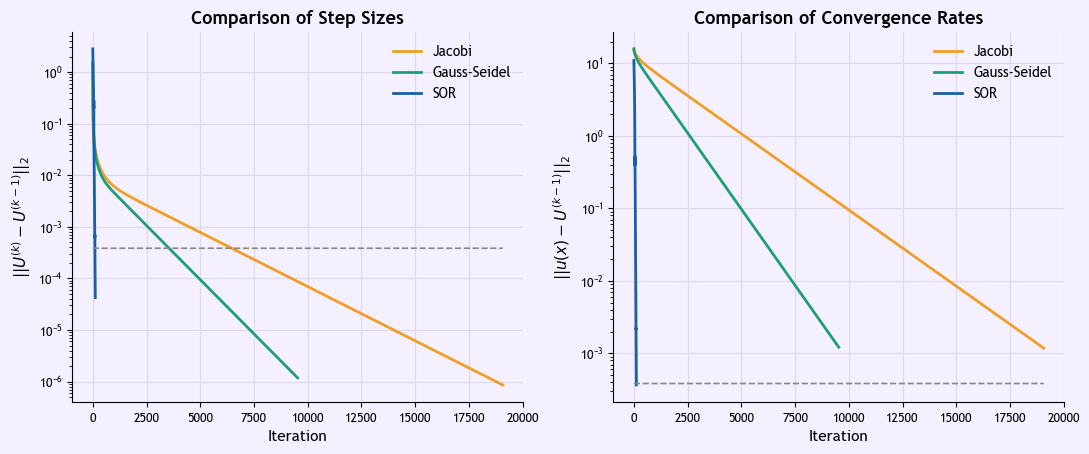

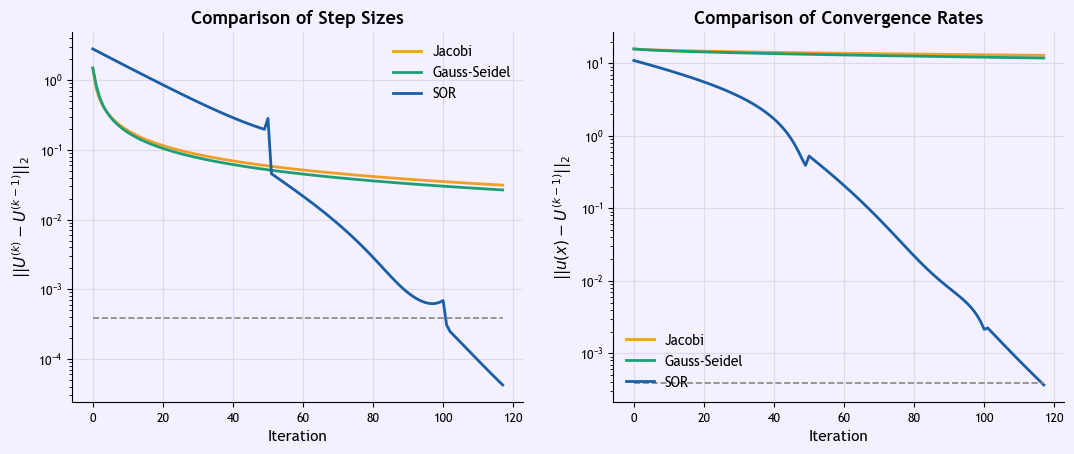

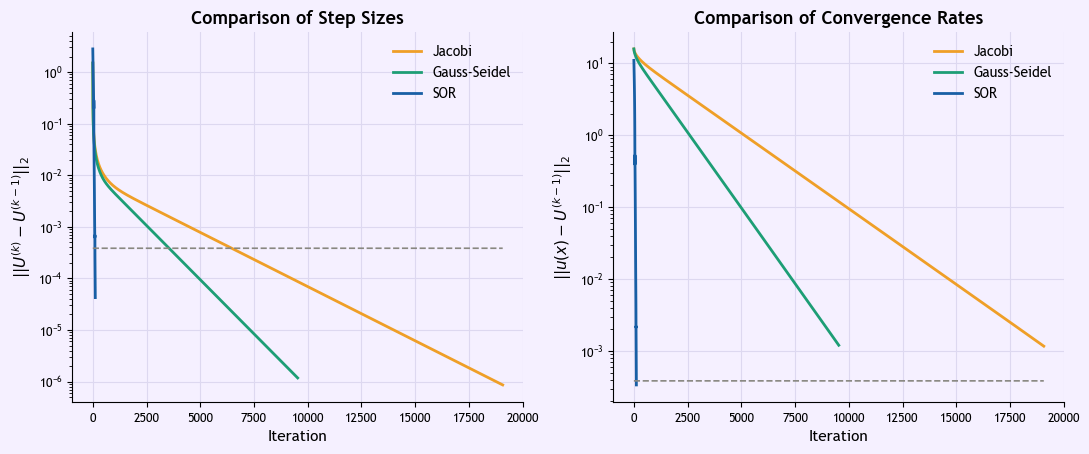

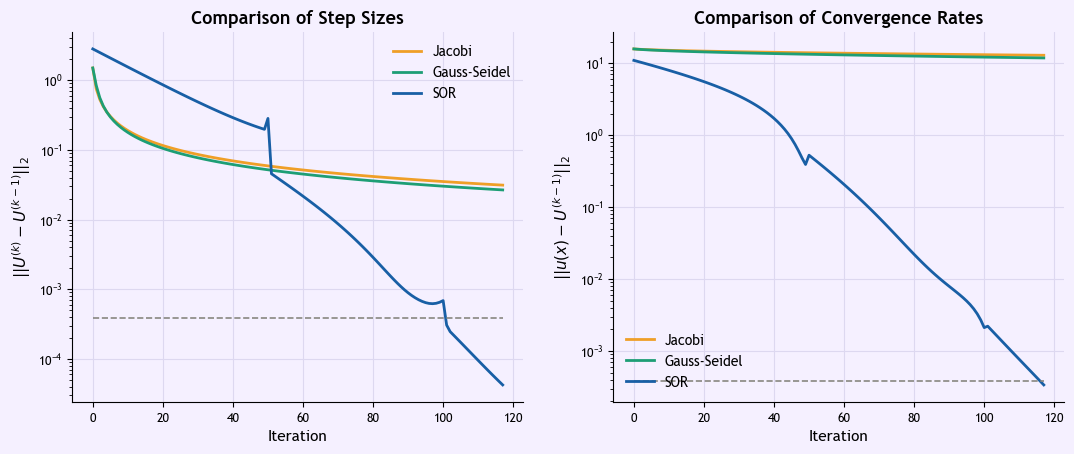

In [ ]:
# Model
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Trebuchet MS', 'Verdana', 'DejaVu Sans'],
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Plotting all the convergence rates
for i in range(2):                     # dua jenis error
    fig = plt.figure(facecolor='#F5F0FF')                 # buat figure baru
    fig.set_figwidth(fig.get_figwidth() * 2)  
    # perlebar ukuran figure

    axes = fig.add_subplot(1, 2, 1)    # subplot kiri pertama
    axes.set_facecolor('#F5F0FF')
    axes.semilogy(range(iterations_J), step_size_J,
                  color='#EF9F27', linewidth=2, label="Jacobi")  
    # plot langkah metode Jacobi
    axes.semilogy(range(iterations_GS), step_size_GS,
                  color='#1D9E75', linewidth=2, label="Gauss-Seidel")  
    # plot langkah Gauss-Seidel
    axes.semilogy(range(iterations_SOR), step_size_SOR,
                  color='#185FA5', linewidth=2, label="SOR")  
    # plot langkah metode SOR
    axes.semilogy(range(iterations_J), numpy.ones(iterations_J) * delta_x**2,
                  '--', color='#888780', linewidth=1.2)  
    # garis batas toleransi
    axes.legend(loc=1, frameon=False)                 # tampilkan legenda atas
    axes.set_title("Comparison of Step Sizes")  
    # judul perbandingan langkah
    axes.set_xlabel("Iteration")       # label sumbu iterasi
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")  
    # norma beda solusi
    axes.grid(True, color='#DDD8F0', linewidth=0.8)

    axes = fig.add_subplot(1, 2, 2)    # subplot kanan pertama
    axes.set_facecolor('#F5F0FF')
    axes.semilogy(range(iterations_J), convergence_J[:, i],
                  color='#EF9F27', linewidth=2, label="Jacobi")  
    # konvergensi metode Jacobi
    axes.semilogy(range(iterations_GS), convergence_GS[:, i],
                  color='#1D9E75', linewidth=2, label="Gauss-Seidel")  
    # konvergensi Gauss-Seidel
    axes.semilogy(range(iterations_SOR), convergence_SOR[:, i],
                  color='#185FA5', linewidth=2, label="SOR")  
    # konvergensi metode SOR
    axes.semilogy(range(iterations_J), numpy.ones(iterations_J) * delta_x**2,
                  '--', color='#888780', linewidth=1.2)  
    # garis batas error
    axes.legend(loc=1, frameon=False)                 # tampilkan legenda atas
    axes.set_title("Comparison of Convergence Rates")  
    # judul perbandingan konvergensi
    axes.set_xlabel("Iteration")       # label sumbu iterasi
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")  
    # norma error solusi
    axes.grid(True, color='#DDD8F0', linewidth=0.8)

    fig = plt.figure(facecolor='#F5F0FF')                 # buat figure kedua
    fig.set_figwidth(fig.get_figwidth() * 2)  
    # perlebar ukuran figure

    axes = fig.add_subplot(1, 2, 1)    # subplot kiri kedua
    axes.set_facecolor('#F5F0FF')
    axes.semilogy(range(iterations_SOR), step_size_J[:iterations_SOR],
                  color='#EF9F27', linewidth=2, label="Jacobi")  
    # langkah Jacobi dipotong
    axes.semilogy(range(iterations_SOR), step_size_GS[:iterations_SOR],
                  color='#1D9E75', linewidth=2, label="Gauss-Seidel")  
    # langkah Gauss-Seidel dipotong
    axes.semilogy(range(iterations_SOR), step_size_SOR,
                  color='#185FA5', linewidth=2, label="SOR")  
    # langkah metode SOR
    axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2,
                  '--', color='#888780', linewidth=1.2)  
    # batas toleransi teori
    axes.legend(loc=1, frameon=False)                 # tampilkan legenda atas
    axes.set_title("Comparison of Step Sizes")  
    # judul perbandingan langkah
    axes.set_xlabel("Iteration")       # label sumbu iterasi
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")  
    # norma beda solusi
    axes.grid(True, color='#DDD8F0', linewidth=0.8)

    axes = fig.add_subplot(1, 2, 2)    # subplot kanan kedua
    axes.set_facecolor('#F5F0FF')
    axes.semilogy(range(iterations_SOR), convergence_J[:iterations_SOR, i],
                  color='#EF9F27', linewidth=2, label="Jacobi")  
    # konvergensi Jacobi dipotong
    axes.semilogy(range(iterations_SOR), convergence_GS[:iterations_SOR, i],
                  color='#1D9E75', linewidth=2, label="Gauss-Seidel")  
    # konvergensi GS dipotong
    axes.semilogy(range(iterations_SOR), convergence_SOR[:, i],
                  color='#185FA5', linewidth=2, label="SOR")  
    # konvergensi metode SOR
    axes.semilogy(range(iterations_SOR), numpy.ones(iterations_SOR) * delta_x**2,
                  '--', color='#888780', linewidth=1.2)  
    # batas error teoritis
    axes.legend(loc=3, frameon=False)                 # legenda posisi bawah
    axes.set_title("Comparison of Convergence Rates")  
    # judul perbandingan konvergensi
    axes.set_xlabel("Iteration")       # label sumbu iterasi
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")  
    # norma error solusi
    axes.grid(True, color='#DDD8F0', linewidth=0.8)

plt.show()   # tampilkan seluruh grafik

# Metode Descent

Satu kasus khusus dari matriks dapat diselesaikan dengan cara iterasi yang sangat kuat. Sebuah matriks dikatakan **simetris positif definit** (SPD) jika:

$$
x^T A x > 0 \quad \forall \quad x \neq 0
$$

Periksa apakah:

$$
A = \begin{bmatrix}
    2 &-1 &0 &0 \\
    -1 & 2 & -1 & 0 \\
    0 & -1 & 2 & -1 \\
    0 & 0 & -1 & 2
\end{bmatrix}
$$

adalah simetris positif definit.

Sekarang definisikan fungsi $\phi: \mathbb R^m \rightarrow \mathbb R$ sebagai:

$$
\phi(u) = \frac{1}{2} u^T A u - u^T f
$$

Ini adalah fungsi kuadratik dalam variabel $u_i$ dan untuk kasus $m = 2$ membentuk mangkuk parabolik. Karena ini fungsi kuadratik, ada minimum unik yaitu $u^\ast$.

Mari kita lihat bagaimana pendekatan seperti ini membantu kita:

Untuk kasus $m = 2$, tuliskan fungsi $\phi(u)$ secara lengkap:

$$
\phi(u) = \frac{1}{2} (A_{11} u_1^2 + A_{12} u_1 u_2 + A_{21} u_1 u_2 + A_{22} u^2_2) - u_1 f_1 - u_2 f_2
$$

Sifat apa dari matriks A yang menyederhanakan persamaan di atas?

Simetri! Ini berarti $A_{21} = A_{12}$ dan persamaan di atas menjadi lebih sederhana:

$$
\phi(u) = \frac{1}{2} (A_{11} u_1^2 + 2 A_{12} u_1 u_2 + A_{22} u^2_2) - u_1 f_1 - u_2 f_2
$$

Sekarang tuliskan dua persamaan yang ketika dievaluasi di $u^\ast$ bernilai 0 yang menyatakan bahwa $u^\ast$ meminimalkan $\phi(u)$.

Karena $u^\ast$ meminimalkan $\phi(u)$, kita tahu bahwa turunan pertama harus nol di titik minimum:

$$\begin{aligned}
    \frac{\partial \phi}{\partial u_1} &= A_{11} u_1 + A_{12} u_2 - f_1 = 0 \\
    \frac{\partial \phi}{\partial u_2} &= A_{21} u_1 + A_{22} u_2 - f_2 = 0
\end{aligned}$$

Perhatikan bahwa persamaan ini dapat ditulis ulang sebagai:

$$
A u = f
$$

Jadi $\min \phi$ ekuivalen dengan menyelesaikan $A u = f$!

Ini adalah jenis reformulasi umum untuk banyak masalah di mana lebih mudah memperlakukan persamaan tertentu sebagai masalah minimisasi daripada menyelesaikannya secara langsung.

Perhatikan bahwa ini tidak persis matriks yang telah kita gunakan untuk masalah Poisson sejauh ini yang sebenarnya simetris negatif definit, meskipun metode yang sama tetap bekerja. Dalam kasus ini kita sebenarnya ingin mencari maksimum dari $\phi$, selain itu semuanya sama.

Perhatikan juga bahwa jika A tidak definit maka nilai eigen dari A akan berganti tanda dan alih-alih minimum atau maksimum yang stabil, kita memiliki titik pelana yang jauh lebih sulit ditangani (GMRES misalnya bisa menangani ini).

# Metode Steepest Descent

Sekarang kita beralih untuk mencari $u^\ast$ yang meminimalkan fungsi $\phi(u)$. Pendekatan paling sederhana disebut **metode steepest descent** yang mencari arah gradien terbesar dari $\phi(u)$ dan bergerak ke arah tersebut.

Secara matematis kita punya:

$$
u^{(k+1)} = u^{(k)} - \alpha^{(k)} \nabla \phi(u^{(k)})
$$

di mana $\alpha^{(k)}$ adalah ukuran langkah yang dipilih dalam arah yang kita inginkan.

Kita dapat mencari $\alpha$ dengan:

$$
\alpha^{(k)} = \min_{\alpha \in \mathbb R} \phi\left(u^{(k)} - \alpha \nabla \phi(u^{(k)})\right)
$$

yaitu $\alpha$ yang membawa kita cukup jauh sehingga jika kita melangkah lebih jauh lagi, $\phi$ akan meningkat.

Ini berarti $\alpha^{(k)} \geq 0$ dan $\alpha^{(k)} = 0$ hanya jika kita berada di minimum $\phi$. Kita dapat menghitung gradien $\phi$ sebagai:

$$
\nabla \phi(u^{(k)}) = A u^{(k)} - f \equiv -r^{(k)}
$$

di mana $r^{(k)}$ adalah residu yang didefinisikan sebagai:

$$
r^{(k)} = f - A u^{(k)}
$$

Melihat kembali definisi $\alpha^{(k)}$ maka kita simpulkan bahwa $\alpha$ yang meminimalkan persamaan tersebut adalah yang memenuhi:

$$
\frac{\text{d} \phi(\alpha)}{\text{d} \alpha} = 0
$$

Untuk mencari ini, perhatikan bahwa:

$$
\phi(u + \alpha r) = \left(\frac{1}{2} u^T A u - u^T f \right) + \alpha(r^T A u - r^T f) + \frac{1}{2} \alpha^2 r^T A r
$$

sehingga turunannya menjadi:

$$
\frac{\text{d} \phi(\alpha)}{\text{d} \alpha} = r^T A u - r^T f + \alpha r^T A r
$$

Dengan menyamakan ini dengan nol maka kita dapatkan:

$$
\alpha = \frac{r^T r}{r^T A r}
$$

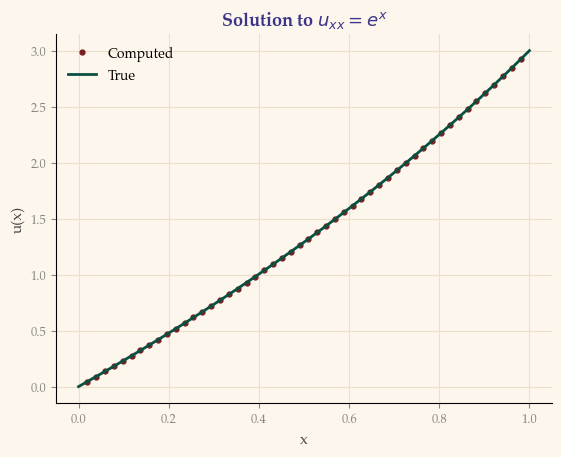

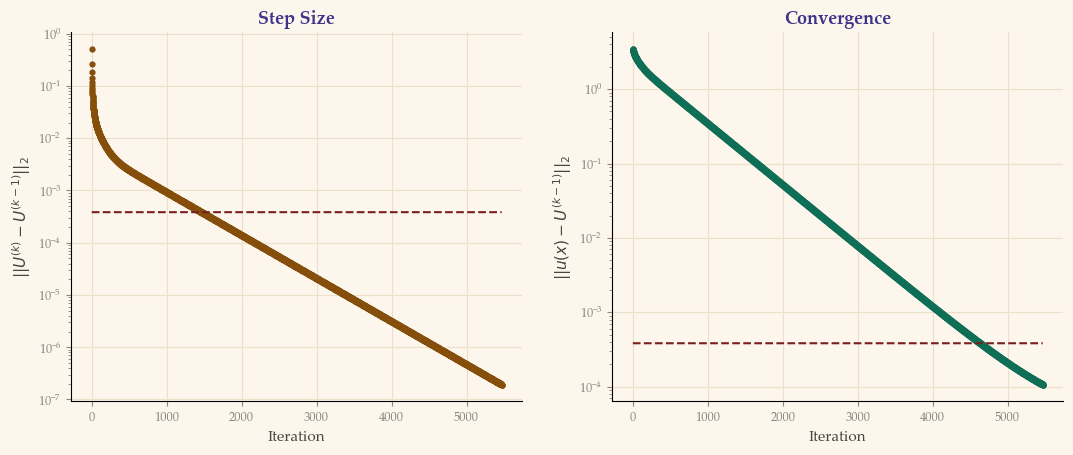

In [ ]:
# Model
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Palatino Linotype', 'Book Antiqua', 'DejaVu Sans'],
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlecolor':    '#3C3489',
    'axes.labelsize':     11,
    'axes.labelcolor':    '#444441',
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'xtick.color':        '#888780',
    'ytick.color':        '#888780',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
})

# Problem setup
a = 0.0                     # batas kiri domain
b = 1.0                     # batas kanan domain
u_a = 0.0                   # nilai batas kiri
u_b = 3.0                   # nilai batas kanan
f = lambda x: numpy.exp(x)  # fungsi sumber e^x
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)  
# solusi analitik sebenarnya

# Descretization
m = 50                                  # jumlah titik interior
x_bc = numpy.linspace(a, b, m + 2)      # grid termasuk batas
x = x_bc[1:-1]                          # grid tanpa batas
delta_x = (b - a) / (m + 1)             # ukuran langkah grid

# Construct matrix A
A = numpy.zeros((m, m))                 # inisialisasi matriks nol
diagonal = numpy.ones(m) / delta_x**2   # nilai diagonal utama
A += numpy.diag(diagonal * 2.0, 0)      # isi diagonal utama
A += numpy.diag(-diagonal[:-1], 1)      # isi diagonal atas
A += numpy.diag(-diagonal[:-1], -1)     # isi diagonal bawah

# Construct right hand side
b = -f(x)                               # vektor ruas kanan
b[0] += u_a / delta_x**2                # koreksi batas kiri
b[-1] += u_b / delta_x**2               # koreksi batas kanan

# Algorithm parameters
MAX_ITERATIONS = 10000   # maksimum iterasi metode
tolerance = 1e-3         # batas toleransi error

# Solve system
U = numpy.empty(m)                       # inisialisasi solusi awal
convergence_SD = numpy.zeros(MAX_ITERATIONS)  
# simpan data konvergensi
step_size_SD = numpy.zeros(MAX_ITERATIONS)    
# simpan ukuran langkah
success = False                          # status konvergensi awal

for k in range(MAX_ITERATIONS):          # loop iterasi steepest descent
    r = b - numpy.dot(A, U)              # hitung residual sistem
    if numpy.linalg.norm(r, ord=2) < tolerance:  
        # cek kondisi konvergensi
        success = True                   # tandai berhasil konvergen
        break                            # hentikan iterasi
        
    alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))  
    # hitung parameter langkah
    U = U + alpha * r                    # update solusi baru

    step_size_SD[k] = numpy.linalg.norm(alpha * r, ord=2)  
    # simpan ukuran langkah
    convergence_SD[k] = numpy.linalg.norm(u_true(x) - U, ord=2)  
    # simpan error solusi
        
if not success:                          # jika gagal konvergen
    print("Iteration failed to converge!")  # tampilkan pesan gagal
    print(convergence_SD[-1])               # tampilkan error akhir
else:
    # Plot result
    fig = plt.figure(facecolor='#FDF6EC')                   # buat figure baru
    axes = fig.add_subplot(1, 1, 1)                         # satu subplot
    axes.set_facecolor('#FDF6EC')
    axes.plot(x, U, 'o',
              color='#791F1F', markersize=3.5, label="Computed")  
    # plot solusi numerik
    axes.plot(x_bc, u_true(x_bc),
              color='#085041', linewidth=2, label="True")  
    # plot solusi analitik
    axes.set_title("Solution to $u_{xx} = e^x$")  
    # judul grafik
    axes.set_xlabel("x")                 # label sumbu x
    axes.set_ylabel("u(x)")              # label sumbu y
    axes.legend(frameon=False)
    axes.grid(True, color='#EDE0C8', linewidth=0.8)

    fig = plt.figure(facecolor='#FDF6EC')                   # figure kedua
    fig.set_figwidth(fig.get_figwidth() * 2)  
    # perlebar ukuran figure
    
    axes = fig.add_subplot(1, 2, 1)                         # subplot kiri
    axes.set_facecolor('#FDF6EC')
    axes.semilogy(list(range(k)), step_size_SD[:k], 'o',
                  color='#854F0B', markersize=3.5)  
    # plot ukuran langkah
    axes.semilogy(list(range(k)), numpy.ones(k) * delta_x**2,
                  '--', color='#791F1F', linewidth=1.5)  
    # batas toleransi teori
    axes.set_title("Step Size")          # judul grafik langkah
    axes.set_xlabel("Iteration")         # label iterasi
    axes.set_ylabel("$||U^{(k)} - U^{(k-1)}||_2$")  
    # norma beda solusi
    axes.grid(True, color='#EDE0C8', linewidth=0.8)

    axes = fig.add_subplot(1, 2, 2)                         # subplot kanan
    axes.set_facecolor('#FDF6EC')
    axes.semilogy(list(range(k)), convergence_SD[:k], 'o',
                  color='#0F6E56', markersize=3.5)  
    # plot konvergensi solusi
    axes.semilogy(list(range(k)), numpy.ones(k) * delta_x**2,
                  '--', color='#791F1F', linewidth=1.5)  
    # batas error teoritis
    axes.set_title("Convergence")        # judul grafik konvergensi
    axes.set_xlabel("Iteration")         # label iterasi
    axes.set_ylabel("$||u(x) - U^{(k-1)}||_2$")  
    # norma error solusi
    axes.grid(True, color='#EDE0C8', linewidth=0.8)

    plt.show()   # tampilkan semua grafik

# Konvergensi Steepest Descent

Konvergensi steepest descent ditentukan oleh bentuk mangkuk parabolik dari $\phi$. 

Jika A adalah kelipatan skalar dari matriks identitas, elipsnya berbentuk lingkaran dan metode ini konvergen dalam m langkah. Jika tidak, konvergensi bergantung pada rasio antara sumbu semi-mayor dan semi-minor elips berdimensi m.

Ini dikontrol oleh nilai eigen terkecil dan terbesar dari matriks A, sehingga steepest descent semakin sulit saat m meningkat untuk masalah Poisson. Hal ini juga terkait dengan condition number matriks dalam norma $\ell_2$.

![Ellipses](./images/ellipses.png)

# Penjelasan Gambar Ellipses

Gambar ini menunjukkan garis-garis kontur berbentuk elips dari fungsi $\phi(u)$. Pusat elips adalah solusi yang kita cari. Metode steepest descent bergerak dari titik awal menuju pusat dengan mengikuti arah penurunan tercepat.

Bentuk elips menentukan kecepatan konvergensi. Jika elipsnya bundar seperti lingkaran, metode ini cepat sampai ke pusat. Tapi jika elipsnya lonjong dan memanjang, metode ini akan bergerak zig-zag dan butuh banyak langkah untuk sampai ke pusat. Semakin lonjong elipsnya, semakin lama waktu yang dibutuhkan.

Iteration count: 1
Iteration count: 8
Iteration count: 83


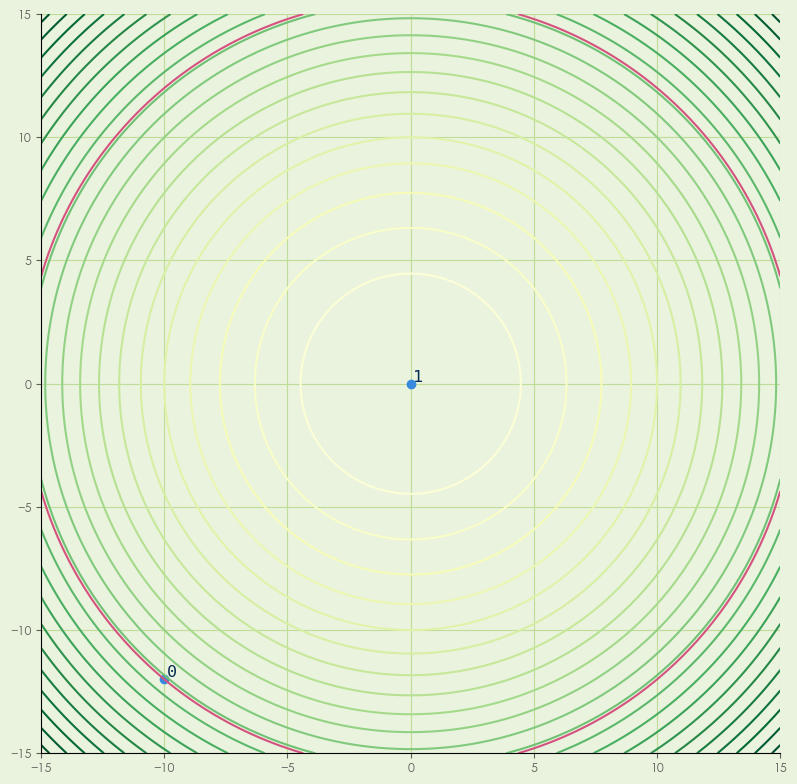

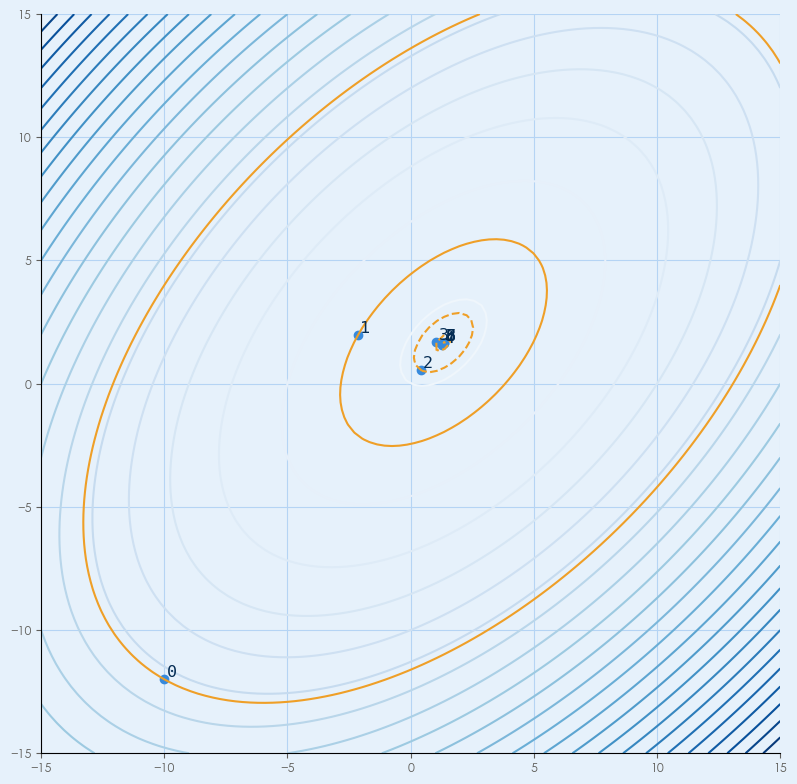

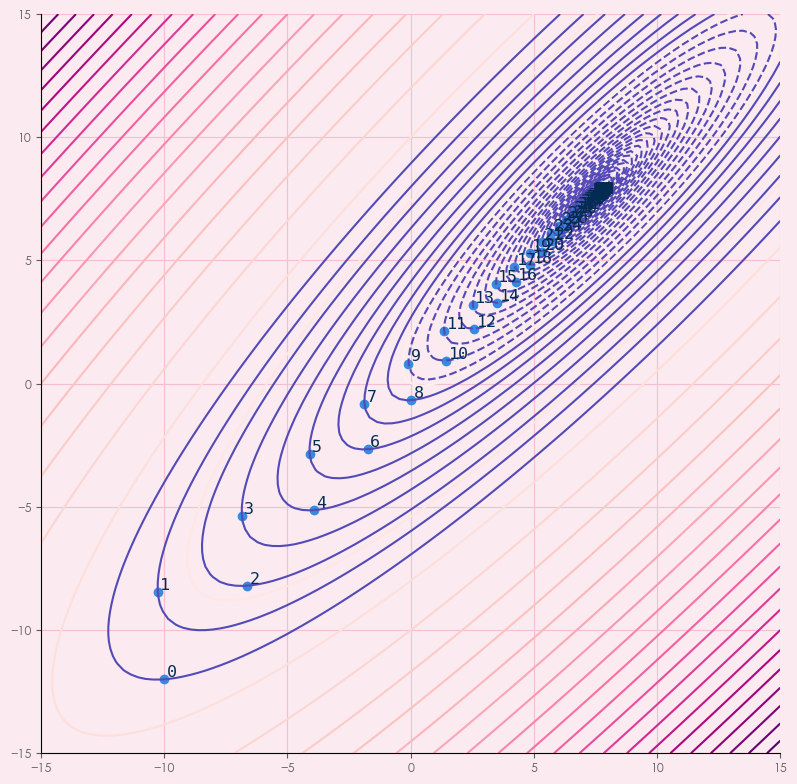

In [ ]:
# Model
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Century Gothic', 'Futura', 'DejaVu Sans'],
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlecolor':    '#042C53',
    'axes.labelsize':     11,
    'axes.labelcolor':    '#2C2C2A',
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'xtick.color':        '#5F5E5A',
    'ytick.color':        '#5F5E5A',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

def steepest_descent(A, U, b, axes):   # fungsi metode steepest descent
    MAX_ITERATIONS = 10000             # maksimum jumlah iterasi
    tolerance = 1e-3                   # batas toleransi error
    success = False                    # status konvergensi awal
    iteration_locations = []           # simpan lokasi iterasi
    for k in range(MAX_ITERATIONS):    # loop utama iterasi
        axes.text(U[0] + 0.1, U[1] + 0.1, str(k),
                  fontsize=12, color='#042C53', fontfamily='monospace')  
        # tampilkan nomor iterasi
        axes.plot(U[0], U[1], 'o', color='#378ADD', markersize=6)    
        # plot titik iterasi
        iteration_locations.append(U)  
        # simpan posisi sekarang
        r = b - numpy.dot(A, U)        
        # hitung residual sistem
        if numpy.linalg.norm(r, ord=2) < tolerance:  
            # cek syarat konvergensi
            success = True             
            # tandai berhasil konvergen
            break                      
            # hentikan proses iterasi

        alpha = numpy.dot(r, r) / numpy.dot(r, numpy.dot(A, r))  
        # hitung panjang langkah
        U = U + alpha * r              
        # update solusi baru
        
    if success:                        
        # jika konvergen berhasil
        return k, iteration_locations  
        # kembalikan iterasi dan lokasi
    else:
        raise Exception("Iteration did not converge.")  
        # tampilkan error gagal

phi = lambda X, Y, A: 0.5 * (A[0, 0] * X**2 + A[0, 1] * X * Y + A[1, 0] * X * Y + A[1, 1] * Y**2) - X * f[0] - Y * f[1]  
# fungsi kuadratik energi

x = numpy.linspace(-15, 15, 100)   # grid sumbu x
y = numpy.linspace(-15, 15, 100)   # grid sumbu y
X, Y = numpy.meshgrid(x, y)        # buat meshgrid 2D

fig = plt.figure(facecolor='#EAF3DE')                 # buat figure pertama
fig.set_figwidth(fig.get_figwidth() * 2)  
# perlebar ukuran figure
fig.set_figheight(fig.get_figheight() * 2)  
# pertinggi ukuran figure
axes = fig.add_subplot(1, 1, 1, aspect='equal')  
# subplot rasio sama
axes.set_facecolor('#EAF3DE')
axes.grid(True, color='#C0DD97', linewidth=0.8)
A = numpy.identity(2)              # matriks identitas 2x2
f = numpy.array([0.0, 0.0])        # vektor nol
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)  
# jalankan metode pertama
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])  
# hitung level fungsi
phi_levels.sort()                  # urutkan level kontur
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='#D4537E')  
# kontur sesuai iterasi
axes.contour(X, Y, phi(X, Y, A), 25, cmap='YlGn')  
# kontur tambahan umum
print("Iteration count: %s" % k)   
# tampilkan jumlah iterasi

fig = plt.figure(facecolor='#E6F1FB')                 # buat figure kedua
fig.set_figwidth(fig.get_figwidth() * 2)  
# perlebar ukuran figure
fig.set_figheight(fig.get_figheight() * 2)  
# pertinggi ukuran figure
axes = fig.add_subplot(1, 1, 1, aspect='equal')  
# subplot rasio sama
axes.set_facecolor('#E6F1FB')
axes.grid(True, color='#B5D4F4', linewidth=0.8)
A = numpy.array([[2, -1], [-1, 2]])  
# matriks simetris positif
f = numpy.array([1.0, 2.0])        
# vektor konstanta baru
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)  
# jalankan metode kedua
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])  
# hitung level fungsi
phi_levels.sort()                  
# urutkan level kontur
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='#EF9F27')  
# kontur sesuai iterasi
axes.contour(X, Y, phi(X, Y, A), 25, cmap='Blues')  
# kontur tambahan umum
print("Iteration count: %s" % k)   
# tampilkan jumlah iterasi

fig = plt.figure(facecolor='#FBEAF0')                 
# buat figure ketiga
fig.set_figwidth(fig.get_figwidth() * 2)  
# perlebar ukuran figure
fig.set_figheight(fig.get_figheight() * 2)  
# pertinggi ukuran figure
axes = fig.add_subplot(1, 1, 1, aspect='equal')  
# subplot rasio sama
axes.set_facecolor('#FBEAF0')
axes.grid(True, color='#F4C0D1', linewidth=0.8)
A = numpy.array([[2, -1.8], [-1.8, 2]])  
# matriks hampir singular
f = numpy.array([1.0, 2.0])        
# vektor konstanta sama
k, iteration_locations = steepest_descent(A, numpy.array([-10.0, -12.0]), f, axes)  
# jalankan metode ketiga
phi_levels = numpy.array([phi(U[0], U[1], A) for U in iteration_locations])  
# hitung level fungsi
phi_levels.sort()                  
# urutkan level kontur
axes.contour(X, Y, phi(X, Y, A), levels=phi_levels, colors='#534AB7')  
# kontur sesuai iterasi
axes.contour(X, Y, phi(X, Y, A), 25, cmap='RdPu')  
# kontur tambahan umum
print("Iteration count: %s" % k)   
# tampilkan jumlah iterasi

# Hubungan Elips dengan Eigenstruktur Matriks A

Setiap elips ini terkait dengan eigenstruktur dari A sehingga:

$$
A v_j - f = \lambda_j (v_j - u^\ast)
$$

untuk suatu $\lambda_j$. Karena kita tahu bahwa $A u^\ast = f$, maka:

$$
A (v_j - u^\ast) = \lambda_j (v_j - u^\ast)
$$

jadi $v_j - u^\ast$ membentuk eigenvector dari matriks A dengan nilai eigen $\lambda_j$ yang sesuai.

Jika kumpulan $\lambda_j$ tertentu tidak berbeda, maka elips sebenarnya adalah lingkaran. Ini menunjukkan bahwa setiap arah yang menunjuk ke $u^\ast$ dalam arah ini adalah eigenvector yang tidak unik dalam sub-ruang tersebut.

Kita juga bisa menghubungkan eigenstruktur ini dengan condition number matriks $\kappa$ secara geometris. Misalkan $v_1$ dan $v_2$ adalah vektor yang terletak di sepanjang kurva $\phi(u) = 1$, maka kita punya:

$$
\frac{1}{2} v^T_j A v_j - v_j^T A u^\ast = 1
$$

Dengan menggabungkan persamaan ini dengan persamaan eigenvector sebelumnya dan mengambil inner-product dengan eigenvector $v_j - u^\ast$, kita dapatkan:

$$
||v_j - u^\ast||^2_2 = \frac{2 + (u^\ast)^T A u^\ast}{\lambda_j}
$$

Sekarang kembali ke $v_1$ dan $v_2$, rasio keduanya adalah:

$$
\frac{||v_1 - u^\ast||_2}{||v_2 - u^\ast||_2} = \sqrt{\frac{\lambda_2}{\lambda_1}} = \sqrt{\kappa_2(A)}
$$

Persamaan terakhir ini memberitahu kita bahwa semakin berbentuk elips sub-ruang ini, semakin sulit untuk menyelesaikan $A u^\ast = f$.

# Interpretasi Proyeksi

Salah satu cara untuk memahami metode steepest descent adalah sebagai metode proyeksi iteratif.

Misalkan kita ingin menyelesaikan $A x = b$, dengan $A \in \mathbb R^{m \times m}$ dan $b \in \mathbb R^m$.

Anggap kita punya dua subruang dalam $\mathbb R^m$, yaitu $\mathcal K$ sebagai subruang pencarian, dan $\mathcal L$ sebagai subruang kendala. Kondisi:

$$
b - A x \perp \mathcal{L}
$$

menunjukkan bahwa vektor residu $b - A x$ ortogonal terhadap subruang $\mathcal{L}$.

Tapi bagaimana $\mathcal K$ masuk ke dalam ini? Ubah pernyataan awal sehingga:

$$
\tilde{x} \in \mathcal{K}
$$

dan kemudian:

$$
b - A \tilde{x} \perp \mathcal{L}
$$

Ini dikenal sebagai kondisi *Petrov-Galerkin*. Jika $\mathcal{K} = \mathcal{L}$ maka ini adalah proyeksi ortogonal.

Untuk mengubahnya menjadi metode iteratif, misalkan tebakan awal kita adalah $x^{(0)}$, maka:

$$
\tilde{x} \in x^{(0)} + \mathcal{K}
$$

sehingga:

$$
b - A \tilde{x} \perp \mathcal{L}
$$

Perhatikan bahwa ini berarti kita memperluas ruang pencarian dengan bagian dari $\text{span}(x^{(0)})$ yang tidak termasuk dalam $\mathcal{K}$.

Kita bisa menulis ulang dalam bentuk yang lebih jelas dengan:

$$
\tilde{x} = x^{(0)} + \delta
$$

di mana $\delta \in \mathcal{K}$ adalah vektor yang akan menjadi langkah kita. Berikan juga indeks pada vektor residu sehingga:

$$
r^{(k)} = b - A x^{(k)}
$$

pada langkah ke-k.

Kemudian kita rumuskan masalah baru sehingga:

$$
r^{(0)} - A \delta \perp \mathcal{L}
$$

yang menghasilkan pernyataan iterasi:

$$\begin{aligned}
    \tilde{x} &= x^{(0)} + \delta, & \quad \quad & \delta \in \mathcal{K} \\
    (r^{(0)} - A \delta) \cdot w &= 0 & \quad \quad & \forall w \in \mathcal{L}
\end{aligned}$$

# Contoh: Proyeksi Satu Dimensi

Metode proyeksi satu dimensi membentuk $\mathcal{K}$ dan $\mathcal{L}$ sehingga:

$$
\mathcal{K} = \text{span}(v) \quad\quad \mathcal{L} = \text{span}(w)
$$

untuk dua vektor $v$ dan $w$. Dalam kasus ini kita dapat menulis pembaruan proyeksi sebagai:

$$
x^{(k+1)} = x^{(k)} + \alpha r
$$

di mana $r$ adalah residu dan:

$$
\alpha = \frac{r \cdot w}{A v \cdot w}
$$

Untuk kasus steepest descent, $v = w = r$ yang menunjukkan bahwa ini adalah proyeksi ortogonal karena $\mathcal{K} = \mathcal{L}$.

Dengan menggeneralisasi sedikit, kita dapat memikirkan metode steepest descent dalam bentuk proyeksi. Misalkan $\mathcal{K} = \mathcal{L}$ dan asumsikan bahwa $A$ adalah simetris positif-definit. Definisikan kesalahan pada langkah ke-k sebagai:

$$
E^{(k)} = x^\ast - x^{(k)}
$$

Dalam kasus ini, pertimbangkan satu langkah dari $k=0$ ke $k=1$. Maka kita akan punya:

$$
r^{(1)} = b - A (x^{(0)} + \delta) = r^{(0)} - A \delta
$$

dan:

$$
A E^{(1)} = r^{(1)} = A(E^{(0)} - \delta)
$$

di mana $\delta$ adalah hasil dari proyeksi sehingga:

$$ 
(r^{(0)} - A \delta) \cdot w = 0 \quad \quad \forall w \in \mathcal{K}
$$